LAB lezione 4: Ising model

# Hands-on on binary classification - The Ising Model

The Ising model provides an interesting example of second order phase transitions, or continous phase transitions. Indeed, evolving with T the spin configurations smoothly vary from the ferromagnetic to the paramagnetic phase and vice versa. A scheme for such phase transition is provided in figure:


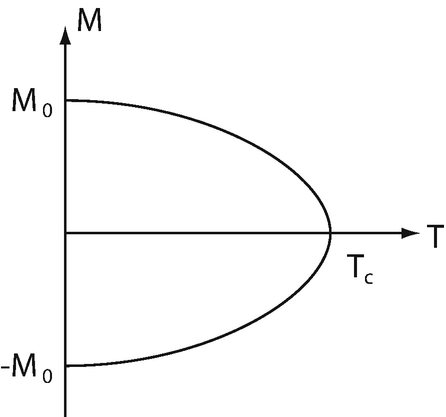

As an exercise of classification, it is possible to set a parameter $k=0.5$, so that if $|m|<k$ we will consider the Ising configuration to be paramagnetic, otherwise a ferromagnetic one.


**For a binary classification, the Binary Cross-Entropy loss function well fits our purpose.** Secondly, instead of a linear regression, we need to perform a different task: one additional layer, linked by Tanh and Sigmoid activation functions with the input and output layers, should work fine.

**Goal**: the purpose of this exercize is to convert the magnetization $m$ into a $\{0,1\}$ label to distinguish paramagnetic phase to the ferromagnetic one. Given a certain spin configuration $\{s \}_l$, the NN should be able to assign a correct label (meaning the paramagnetic or the ferromagnetic phase).

**Steps**


1.   Instantiate the FeedForward class template, this time with a new NN model architecture.
2.   Load the dataset and modify the labels, ranging in the $[-1,1]$ interval, into a binary set $\{0,1\}$. To perform such operation, it could be useful to insert the following command:
```
labels[np.abs(labels) > 0.5] = 1
labels[np.abs(labels) <= 0.5] = 0
```
With such option, all the $m$ values in the range $[-0.5;+0.5]$  will be addressed to be $0$, while in the other intervals they will be $0$. The variable label is now a list containing $0$ and $1$ instead of $m$.

3.   Split the dataset into a training and a testing batches
4.   Train the model
5.   Evaluate the model performances during the test on the sub-dataset by using the balanced accuracy





**Hints**



1.   Recycle the FeedForward class template from the Ising regression, rearranging the NN architecture
2.   To implement the NN architecture, it would be useful to introduce a hidden layers. As activation functions, a Tanh and a sigmoid should turn to work fine.

3.   The number of inputs is given by the number of cells from the data, and the output is equal to 1 (the magnetization value).
4.   When performing a regression, the best choice for the loss function usually is the BCE loss:
```
nn.BCELoss()
```
5.   when training the data, it could be useful to deploy the following methods:

```
dataset_train = TensorDataset(data_for_training, labels_for_training)
loader_train = DataLoader(dataset_train, batch_size=size_we_want, shuffle=True)
```
With such a setting, it is possible to train the model without any concern about the batch size during the for loop:
```
for data in loader_train:
    input_data, label = data
    ## TRAINING ##
```
6.   remember to employ the [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) and [balanced_accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html) methods from sklearn!


/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_68261/371522798.py:94: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_data[np.abs(y_data) > 0.5] = 1
/var/folders/x2/gw8lnpfn3rl_bq8qbsh1pblm0000gn/T/ipykernel_68261/371522798.py:96: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_data[np.abs(y_data) <= 0.5] = 0


Epoch 010/99 | Loss: 0.0550 | Acc: 0.9975 | Bal. Acc: 0.9985
Epoch 020/99 | Loss: 0.0081 | Acc: 1.0000 | Bal. Acc: 1.0000
Epoch 030/99 | Loss: 0.0036 | Acc: 1.0000 | Bal. Acc: 1.0000
Epoch 040/99 | Loss: 0.0021 | Acc: 1.0000 | Bal. Acc: 1.0000
Epoch 050/99 | Loss: 0.0014 | Acc: 1.0000 | Bal. Acc: 1.0000
Epoch 060/99 | Loss: 0.0010 | Acc: 1.0000 | Bal. Acc: 1.0000
Epoch 070/99 | Loss: 0.0008 | Acc: 1.0000 | Bal. Acc: 1.0000
Epoch 080/99 | Loss: 0.0006 | Acc: 1.0000 | Bal. Acc: 1.0000
Epoch 090/99 | Loss: 0.0005 | Acc: 1.0000 | Bal. Acc: 1.0000
Epoch 100/99 | Loss: 0.0004 | Acc: 1.0000 | Bal. Acc: 1.0000


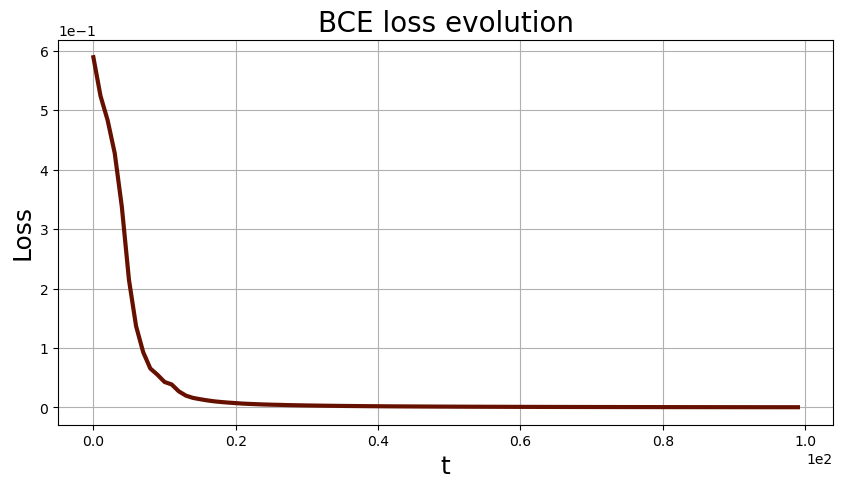

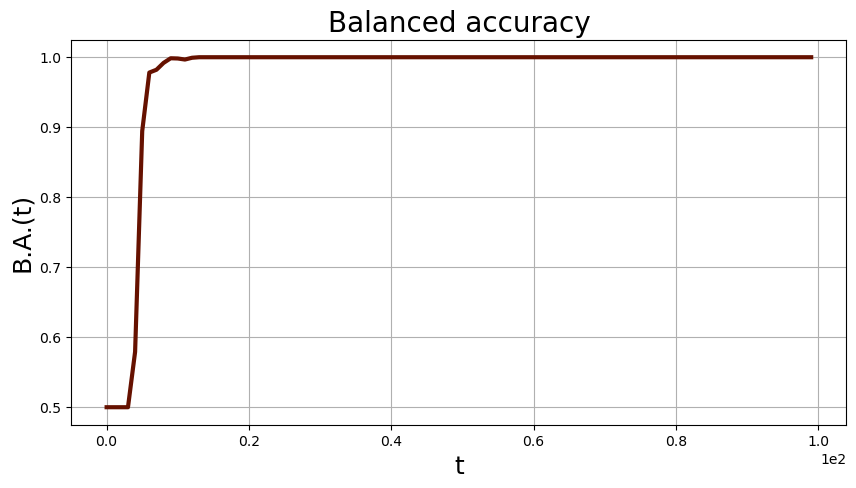

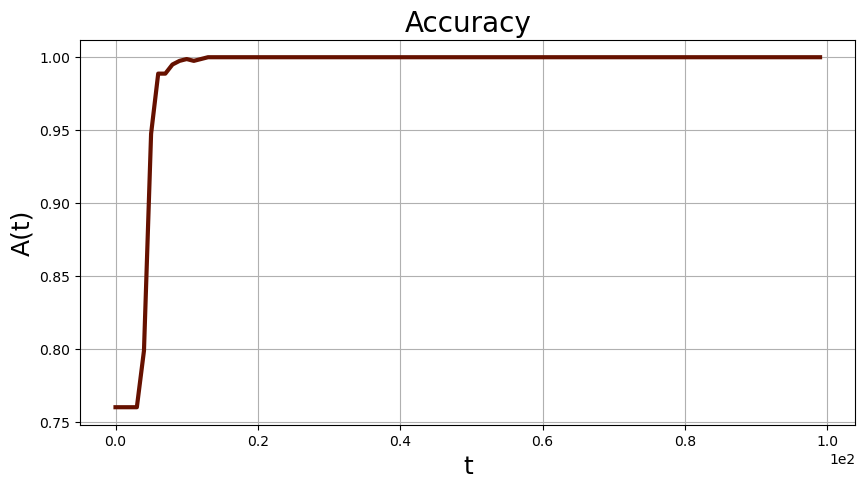

----------------------------------------
TEST ACCURACY:       0.98
TEST BALANCED ACCURACY: 0.9708624708624709
----------------------------------------


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

# Make usage of accuracy_score and balanced_accuracy_score from sklearn
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split


class BinaryClassificationNN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()

        # DEFINE HERE THE LAYERS
        self.layers = nn.Sequential(
                nn.Linear(input_size, 16),
                nn.Tanh(),
                nn.Linear(16,8),
                nn.Sigmoid(),
                nn.Linear(8, output_size),
                nn.Sigmoid()        
        )

        # DEFINE HERE THE OPTIMIZER
        self.optimizer = optim.Adam(self.parameters(), lr=0.01)

        # DEFINE HERE THE LOSS
        self.criterion = nn.BCELoss()


    def forward(self, x):
        return self.layers(x)

    def train_step(self, inputs, labels):
        """
        :param inputs:
        :param labels:
        :return:
        """
        # set to zero the parameter gradients
        self.optimizer.zero_grad()

        # implement forward + backward + optimize sequence
        outputs = self.forward(inputs)
        labels = labels.view(-1,1)
        loss = self.criterion(outputs, labels)
        loss.backward()
        self.optimizer.step()
        return loss.item()


def print_trend(epochs, loss_evolution, title='Loss function', y_label='L(t)'):
    plt.figure(figsize=(10, 5))
    plt.title(title, fontsize=20)
    plt.plot(epochs, loss_evolution, color='#661100', alpha=1, lw=3)
    plt.ticklabel_format(axis='both', style='sci', scilimits=(2, 4))
    plt.grid(True)
    plt.xlabel('t', fontsize=18)
    plt.ylabel(y_label, fontsize=18)
    plt.show()


class MyDataset(Dataset):
    """
    Face Landmarks dataset
    """
    def __init__(self, input_data, labels):
        self.labels = labels
        self.input_data = input_data

    def __len__(self):
        return len(self.input_data)

    def __getitem__(self, idx):
        return {'label': self.labels[idx], 'input': self.input_data[idx]}


def main():

    # Load the dataset
    raw_data = np.load("ISING_1000step.npz")
    x_data, y_data = raw_data["grid"], raw_data["magnetizations"]

    # Convert to tensor format
    x_data = torch.tensor(x_data, dtype=torch.float32)
    y_data = torch.tensor(y_data, dtype=torch.float32)
    y_data = torch.reshape(y_data, shape=(1000, 1))


    # convert the magnetization labels y into phase labels ##
    # |m| >.5 -> ferromagnetic
    y_data[np.abs(y_data) > 0.5] = 1
    # |m| <.5 -> paramagnetic
    y_data[np.abs(y_data) <= 0.5] = 0

    # Split into train & test dataset
    train_data, test_data, train_labels, test_labels = train_test_split(x_data, y_data, test_size=.2)


    # get the number of features (len_data, n_features)
    _, input_size = train_data.size()
    output_size = 1

    train_dataset = MyDataset(train_data, train_labels)

    # Create dataloaders for storing and shuffling data:
    train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)

    # Initialize the NN model (binary classificator)
    binary_classificator = BinaryClassificationNN(input_size, output_size)

    loss_evolution, acc_score, bal_acc_score = [], [], []
    epochs = range(100)

    # train the model and plot 1) loss 2) accuracy 3) balanced accuracy
    for ep in epochs:
        counter = 0
        '''batch_loss = 0
        acc = 0
        bal_acc = 0'''
        batch_losses, batch_acc, batch_bal_acc = [], [], []

        for batch in train_loader:
            counter += 1
            input_data, label = batch['input'], batch['label']

            # train the model here
            loss = binary_classificator.train_step(input_data, label)
            batch_losses.append(loss)
            # Get the predictions in order to plot the accuracy
            with torch.no_grad():
                y_prob = binary_classificator(input_data)
                y_pred_np = (y_prob >= 0.5).to(torch.float32).cpu().numpy()
                y_true_np = label.cpu().numpy()

            batch_acc.append(accuracy_score(y_true_np, y_pred_np))
            batch_bal_acc.append(balanced_accuracy_score(y_true_np, y_pred_np))

        # Salva i valori medi per l'epoca corrente
        loss_evolution.append(np.mean(batch_losses))
        acc_score.append(np.mean(batch_acc))
        bal_acc_score.append(np.mean(batch_bal_acc))
        
        if (ep + 1) % 10 == 0:
            print(f"Epoch {ep+1:03d}/{max(epochs)} | Loss: {loss_evolution[-1]:.4f} | Acc: {acc_score[-1]:.4f} | Bal. Acc: {bal_acc_score[-1]:.4f}")

    print_trend(epochs, loss_evolution, 'BCE loss evolution', y_label='Loss')
    print_trend(epochs, bal_acc_score, 'Balanced accuracy', y_label='B.A.(t)')
    print_trend(epochs, acc_score, 'Accuracy', y_label='A(t)')

    # TODO: test the performance of the model using the test dataset and by measuring the accuracy and the balanced accuracy
    # use accuracy_score and balanced_accuracy_score from sklearn.metrics package, see
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html
    with torch.no_grad():
        test_prob = binary_classificator(test_data)
        test_pred = (test_prob >= 0.5).to(torch.float32).cpu().numpy()
        test_true = test_labels.cpu().numpy()

        print("-" * 40)
        print(f'TEST ACCURACY:      ',accuracy_score(test_true, test_pred))
        print(f'TEST BALANCED ACCURACY:',balanced_accuracy_score(test_true, test_pred))
        print("-" * 40)

if __name__ == "__main__":
    main()


# Facultative hands-on on multiclass classification - The Boson Higgs Challenge

**The dataset:**

In a nutshell, the **data set contains a mixture of simulated signal and background events**, built from simulated events **provided by the ATLAS collaboration at CERN**. The simulated events that you will have in your hands are the same that physicists used.

*   It is a CSV file containing 250000 events.
*   The dataset is unbalanced
*   There are 21 features + 1 label (signal/noise)





**The goal:** your goal is to construct a neural network binary classifier to classify signals (Higgs decaying to leptons) from background noise.

**Steps**


1.   Instantiate the FeedForward class template, this time with a new NN model architecture.
2.   Load the csv dataset by using Pandas
```
raw_data = pd.read_csv("training_processed.csv")
```
3.   Split the dataset into a training and a testing batches
4.   Train the model
5.   Evaluate the model performances during the test on the testing dataset

Caricamento del dataset Higgs in corso...

--- Inizio Addestramento (Analisi Dati ATLAS) ---
Epoca 05/50 | Loss Media: 0.3938
Epoca 10/50 | Loss Media: 0.3826
Epoca 15/50 | Loss Media: 0.3773
Epoca 20/50 | Loss Media: 0.3745
Epoca 25/50 | Loss Media: 0.3732
Epoca 30/50 | Loss Media: 0.3710
Epoca 35/50 | Loss Media: 0.3699
Epoca 40/50 | Loss Media: 0.3689
Epoca 45/50 | Loss Media: 0.3686
Epoca 50/50 | Loss Media: 0.3675


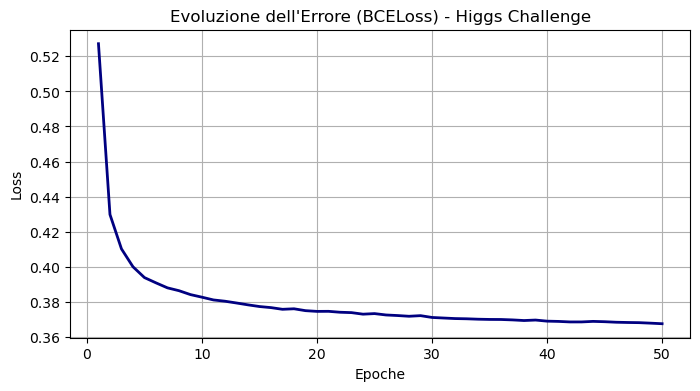


--- Valutazione sul Test Set (Generalizzazione) ---
Accuratezza Standard: 0.8336 (83.4%)
Balanced Accuracy:    0.8012 (80.1%)


In [23]:
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt

# 1. DEFINIZIONE DEL MODELLO NEURALE
# Architettura ottimizzata per estrarre pattern fisici complessi.
class HiggsClassifier(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        
        # Una rete sufficientemente profonda per catturare la cinematica dei decadimenti.
        # L'ultimo strato è una Sigmoide poiché usiamo la Binary Cross Entropy (BCELoss).
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, output_size),
            nn.Sigmoid()
        )
        
        # Optimizer Adam: ideale per dataset complessi e rumorosi come quelli dell'LHC
        self.optimizer = optim.Adam(self.parameters(), lr=0.001)
        # Funzione di Loss per classificazione binaria (Segnale vs Fondo)
        self.criterion = nn.BCELoss()

    def forward(self, x):
        return self.layers(x)

    def train_step(self, inputs, labels):
        self.optimizer.zero_grad()
        outputs = self.forward(inputs)
        
        # Assicuriamoci che le etichette siano vettori colonna
        labels = labels.view(-1, 1)
        loss = self.criterion(outputs, labels)
        
        loss.backward()
        self.optimizer.step()
        return loss.item()

def main():
    # 2. CARICAMENTO E PREPARAZIONE DEL DATASET
    print("Caricamento del dataset Higgs in corso...")
    try:
        df = pd.read_csv("atlas-higgs-challenge-2014-v2.csv")
    except FileNotFoundError:
        print("File non trovato.")
        return

    # Trasformiamo la Label in numerica (0 e 1)
    if 'Label' in df.columns:
        df['Label'] = df['Label'].map({'s': 1.0, 'b': 0.0})
        y = df['Label'].values
    else:
        y = df.iloc[:, -1].values

    # PULIZIA DATI: 
    # 1. Rimuoviamo le colonne non numeriche che PyTorch non può gestire
    # 2. 'KaggleSet' è una stringa nel dataset originale, va rimossa!
    # 3. 'KaggleWeight' e 'Weight' vanno rimossi per evitare che il modello "bari"
    cols_to_drop = ['Label', 'EventId', 'Weight', 'KaggleSet', 'KaggleWeight']
    X_df = df.drop(columns=cols_to_drop, errors='ignore')

    # Convertiamo forzatamente tutto il DataFrame in float
    # Questo trasformerà eventuali stringhe residue in numeri o darà errore subito
    X = X_df.astype(float).values

    # Ora la conversione funzionerà correttamente
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    input_size = X_tensor.shape[1]
    output_size = 1

    # 3. SPLIT DEL DATASET E CREAZIONE DATALOADER
    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)

    # Inizializziamo il modello
    model = HiggsClassifier(input_size, output_size)

    # 4. FASE DI TRAINING
    n_epochs = 50
    loss_history = []
    
    print("\n--- Inizio Addestramento (Analisi Dati ATLAS) ---")
    for epoch in range(n_epochs):
        epoch_losses = []
        for batch_x, batch_y in train_loader:
            loss = model.train_step(batch_x, batch_y)
            epoch_losses.append(loss)
            
        mean_loss = np.mean(epoch_losses)
        loss_history.append(mean_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoca {epoch+1:02d}/{n_epochs} | Loss Media: {mean_loss:.4f}")

    # Plot dell'andamento dell'errore
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_epochs + 1), loss_history, color='navy', linewidth=2)
    plt.title("Evoluzione dell'Errore (BCELoss) - Higgs Challenge")
    plt.xlabel("Epoche")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    # 5. FASE DI TESTING E VALUTAZIONE
    print("\n--- Valutazione sul Test Set (Generalizzazione) ---")
    with torch.no_grad():
        y_pred_probs = model(X_test)
        
        # Applicazione della soglia di decisione: Probabilità >= 50% -> Segnale (1)
        y_pred_classes = (y_pred_probs.numpy() >= 0.5).astype(float)
        y_true_np = y_test.numpy()

        # Calcolo delle Metriche
        acc = accuracy_score(y_true_np, y_pred_classes)
        bal_acc = balanced_accuracy_score(y_true_np, y_pred_classes)

        print(f"Accuratezza Standard: {acc:.4f} ({acc*100:.1f}%)")
        print(f"Balanced Accuracy:    {bal_acc:.4f} ({bal_acc*100:.1f}%)")
        
if __name__ == "__main__":
    main()